In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Use STIX fonts for math symbols
plt.rcParams['text.usetex'] = True # enable LaTeX rendering

# Plot time history of Nu and Sh over time

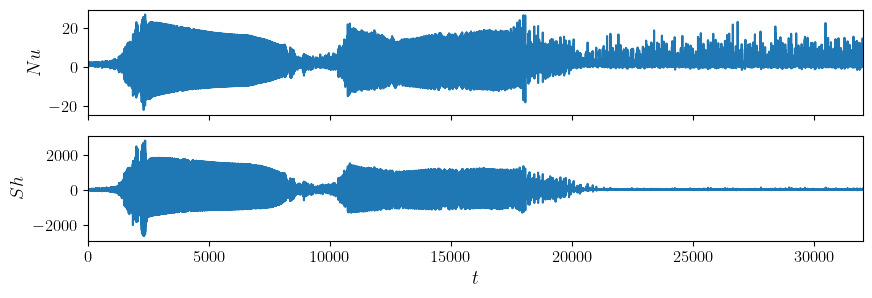

Time-averaged Nu= 3.0253798301705714
Time-averaged Sh= 5.621493844808572
Time-averaged gamma= 0.009675226584129148
gamma from (time-averaged Nu,Sh)= 0.03716223522579399


In [2]:
from func import *

[time,Nu]=readdata("Data/DNS/case3_kz6_nx768/energy.asc",17)
[_,Sh]=readdata("Data/DNS/case3_kz6_nx768/energy.asc",22)
start=0
end = 32000

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(10, 3))
gs = GridSpec(2, 1, figure=fig)

ax1 = fig.add_subplot(gs[0,0])  # row 0, both columns
ax2 = fig.add_subplot(gs[1,0])  # row 1, both columns

# --- Plot 1: Nu vs t ---
ax1.plot(time[start:end], Nu[start:end], '-')
# ax1.set_xlabel(r'$t$', fontsize=14)
ax1.set_ylabel(r'$Nu$', fontsize=14)
ax1.set_xlim([0,32000])
ax1.set_xticklabels([], fontsize=14)
ax1.tick_params(axis='both', labelsize=12)

# --- Plot 2: Sh vs t ---
ax2.plot(time[start:end], Sh[start:end], '-')
ax2.set_xlabel(r'$t$', fontsize=14)
ax2.set_ylabel(r'$Sh$', fontsize=14)
ax2.set_xlim([0,32000])
ax2.tick_params(axis='both', labelsize=12)

plt.savefig('Data/DNS/case3_kz6_nx768/TimeHistory_NuSh.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


gamma = 0.01*2*Sh[25000:end]/Nu[25000:end]
print("Time-averaged Nu=",np.mean(Nu[25000:end]))
print("Time-averaged Sh=",np.mean(Sh[25000:end]))
print("Time-averaged gamma=",np.mean(gamma))
print("gamma from (time-averaged Nu,Sh)=",0.01*2*np.mean(Sh[25000:end])/np.mean(Nu[25000:end]))

# Compare Nu and Sh between different initial conditions (kz=6 and kz=1) and different mesh 256x129

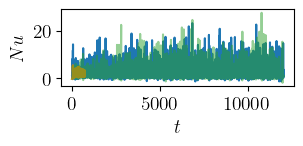

In [3]:
from func import *
plt.figure(figsize=(3, 1))
start=0
end = -1
[time,Nu]=readdata("Data/DNS/case3_kz6_nx768/energy.asc",17)
plt.plot(time[20000:32000]-20000,Nu[20000:32000],'-')

[time,Nu]=readdata("Data/DNS/case3_kz1_nx768/energy.asc",17)
plt.plot(time[start:end],Nu[start:end],'-')

[time,Nu]=readdata("Data/DNS/case3_kz1_nx256/energy.asc",17)
plt.plot(time[start:12000],Nu[start:12000],'-',alpha=0.5)

plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$Nu$', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.close()

# [time,Sh]=readdata("Data/DNS/case3_kz1_nx256/energy.asc",22)
# plt.figure(figsize=(10, 2))
# plt.plot(time[start:end],Sh[start:end],'-')
# plt.xlabel(r'$t$', fontsize=14)
# plt.ylabel(r'$Sh$', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.show()
# plt.close()


# gamma = 0.01*2*Sh[start:end]/Nu[start:end]
# print("Time-averaged Nu=",np.mean(Nu[start:end]))
# print("Time-averaged Sh=",np.mean(Sh[start:end]))
# print("Time-averaged gamma=",np.mean(gamma))
# print("gamma from (time-averaged Nu,Sh)=",0.01*2*np.mean(Sh[start:end])/np.mean(Nu[start:end]))

# Load (save) time history of horizontally averaged density

In [4]:
# def getpath(path):
#     import glob
#     from natsort import natsorted
#     file_paths = glob.glob(path)
#     return natsorted(file_paths)

# def loaddata_channelflow_ddc_new(path,dt=1):
#     import numpy as np
#     import glob
#     import pandas as pd
#     file_list = getpath(path)
#     nstep = len(file_list)
#     t = np.linspace(0, nstep, nstep) * dt

#     # load data
#     T_mean = []
#     S_mean = []
#     T_gradient = []
#     S_gradient = []
#     T_flux = []
#     S_flux = []
#     y = []
#     for file in file_list:
#         df = pd.read_csv(file, skiprows=1)
#         array = df.values
#         y = array[:,0]
#         T_mean.append(array[:,1])
#         T_gradient.append(array[:,2])
#         T_flux.append(array[:,3])
#         S_mean.append(array[:,4])
#         S_gradient.append(array[:,5])
#         S_flux.append(array[:,6])

#     T_mean = np.array(T_mean)
#     S_mean = np.array(S_mean)
#     T_gradient = np.array(T_gradient)
#     S_gradient = np.array(S_gradient)
#     T_flux = np.array(T_flux)
#     S_flux = np.array(S_flux)

#     return t,y,T_mean,S_mean,T_gradient,S_gradient,T_flux,S_flux

# [t,z,tm,sm,_,_,_,_] = loaddata_channelflow_ddc_new('../2D/DNS/case3_yangpaper_Pr10_Ra1e6_Ri1/profiles/meanprofile*.csv')

# Lambda = 2
# Density = (Lambda*sm-tm)/(Lambda-1)

# import numpy as np
# np.savez("Data/DNS/case3_kz6_nx768/meandata.npz", time=t, z=z, temp = tm, salt = sm, dens = Density)

C:\Users\jms24002\AppData\Local\Temp\ipykernel_4696\2473762506.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BuPu')


density shape  (32001, 384)


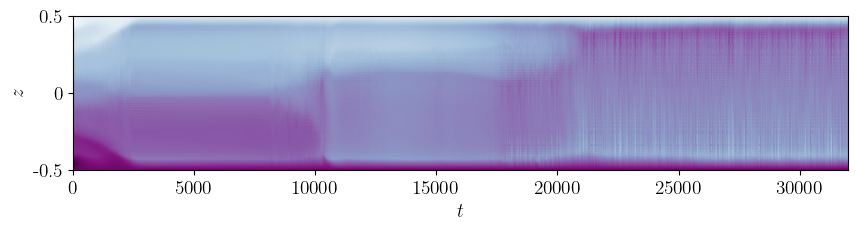

In [ ]:
from func import *
import matplotlib.cm as cm
cmap = cm.get_cmap('BuPu')
import numpy as np
data = np.load("Data/DNS/case3_kz6_nx768/meandata.npz", allow_pickle=True)
t = data["time"]
z = data["z"]
Temp = data["temp"]
Salt = data["salt"]
Density = data["dens"]
print("density shape ", np.shape(Temp))

plt.figure(figsize=(10, 2))
X, Z = np.meshgrid(t, z)
cax = plt.pcolormesh(X,Z,Density.T, cmap=cmap,shading='auto')
plt.xlabel(r'$t$',fontsize=14)
plt.ylabel(r'$z$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks([-0.5, 0, 0.5],['-0.5','0','0.5'],fontsize=14)
plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.tick_params(axis='y', which='both', left=True, right=False, labelleft=True)
# plt.title(r'$\langle \rho\rangle_{h,t}$')


plt.savefig('Data/DNS/case3_kz6_nx768/TimeHistory_meanDensity.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## save mean profiles at given intervals for two layers and one layer

In [6]:
import numpy as np
data = np.load("Data/DNS/case3_kz6_nx768/meandata.npz")
t = data["time"]
z = data["z"]
Temp = data["temp"]
Salt = data["salt"]
Density = data["dens"]


def save_data(tm,sm,dens,name,start=0,end=-1):
    mean_T = np.mean(tm[start:end,:], axis=-2)
    mean_S = np.mean(sm[start:end,:], axis=-2)
    mean_Dens = np.mean(dens[start:end,:], axis=-2)
    data = np.array([mean_T, mean_S, mean_Dens])
    np.savetxt(name, data.T, delimiter=', ')

name = 'Data/DNS/case3_kz6_nx768/noslip_channelflowddc_2steps.csv'
save_data(Temp,Salt,Density,name,3000,8000)

name = 'Data/DNS/case3_kz6_nx768/noslip_channelflowddc_1steps.csv'
save_data(Temp,Salt,Density,name,25000,32000)

# Plot snapshots of density visualizing layering behavior

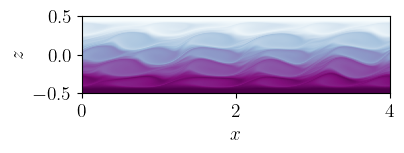

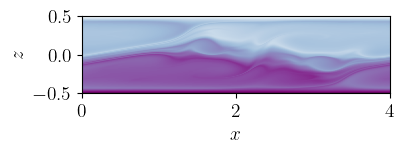

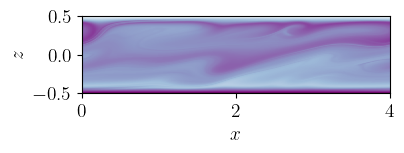

In [1]:
from func import *
  
### onset of simulation: roll flow structures: t=100
plt.figure(figsize=(4, 1))
[z,x,t] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/t300.nc',1)
[z,x,s] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/s300.nc',1)
T = t-z
S = s-z
Lambda = 2
rho = (Lambda*S-T)/(Lambda-1)
X, Y = np.meshgrid(x, z)
cax = plt.pcolormesh(X,Y,rho.T, shading='auto',vmin=-0.5,vmax=0.5, cmap='BuPu')
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$z$', fontsize=14)
plt.xticks([0,2,4],fontsize=14)
plt.yticks([-0.5, 0, 0.5],fontsize=14)
plt.xlim(0, 4)
plt.ylim(-0.5, 0.5)
plt.gca().set_aspect('equal')
# cbar = plt.colorbar(cax, ticks=[-0.5, 0, 0.5], shrink=1.0, aspect=10)
plt.savefig('Data/DNS/case3_kz6_nx768/Density_300.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### two layers: t=6000
plt.figure(figsize=(4, 1))
[z,x,t] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/t6000.nc',1)
[z,x,s] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/s6000.nc',1)
T = t-z
S = s-z
Lambda = 2
rho = (Lambda*S-T)/(Lambda-1)
X, Y = np.meshgrid(x, z)
cax = plt.pcolormesh(X,Y,rho.T, shading='auto',vmin=-0.5,vmax=0.5, cmap='BuPu')
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$z$', fontsize=14)
plt.xticks([0,2,4],fontsize=14)
plt.yticks([-0.5, 0, 0.5],fontsize=14)
plt.xlim(0, 4)
plt.ylim(-0.5, 0.5)
plt.gca().set_aspect('equal')
# cbar = plt.colorbar(cax, ticks=[-0.5, 0, 0.5], shrink=1.0, aspect=10)
plt.savefig('Data/DNS/case3_kz6_nx768/Density_6000.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()



### one layers: t=30000
plt.figure(figsize=(4, 1))
[z,x,t] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/t30000.nc',1)
[z,x,s] = z_averaged_scalar('Data/DNS/case3_kz6_nx768/flowfields/s30000.nc',1)
T = t-z
S = s-z
Lambda = 2
rho = (Lambda*S-T)/(Lambda-1)
X, Y = np.meshgrid(x, z)
cax = plt.pcolormesh(X,Y,rho.T, shading='auto',vmin=-0.5,vmax=0.5, cmap='BuPu')
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$z$', fontsize=14)
plt.xticks([0,2,4],fontsize=14)
plt.yticks([-0.5, 0, 0.5],fontsize=14)
plt.xlim(0, 4)
plt.ylim(-0.5, 0.5)
plt.gca().set_aspect('equal')
# cbar = plt.colorbar(cax, ticks=[-0.5, 0, 0.5], shrink=1.0, aspect=10)
plt.savefig('Data/DNS/case3_kz6_nx768/Density_30000.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

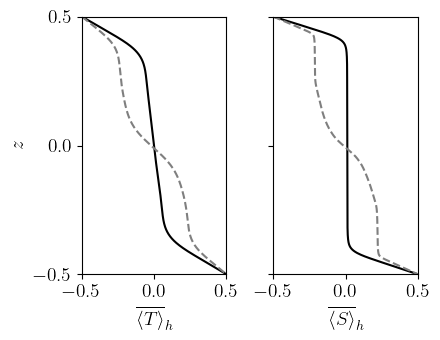

In [8]:

def ypoints(a, b, Ny):
    ypts = np.zeros(Ny)
    c = 0.5 * (b + a)
    r = 0.5 * (b - a)
    piN = np.pi / (Ny - 1)
    for i in range(Ny):
        ypts[i] = c + r * np.cos(piN * i)
    return ypts


y_ddc = ypoints(-0.5,0.5,384)

noslip_ddc = np.loadtxt('Data/DNS/case3_kz6_nx768/noslip_channelflowddc_2steps.csv', delimiter=',')
mtemp_ddc_2steps = noslip_ddc[:, 0]
msalt_ddc_2steps = noslip_ddc[:, 1]
mdens_ddc_2steps = noslip_ddc[:, 2]

noslip_ddc = np.loadtxt('Data/DNS/case3_kz6_nx768/noslip_channelflowddc_1steps.csv', delimiter=',')
mtemp_ddc_1steps = noslip_ddc[:, 0]
msalt_ddc_1steps = noslip_ddc[:, 1]
mdens_ddc_1steps = noslip_ddc[:, 2]


# mtemp_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_temp.csv', delimiter=',')[::-1]
# msalt_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_salt.csv', delimiter=',')[::-1]
# mdens_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_dens.csv', delimiter=',')[::-1]
# tempflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/temp_flux.csv', delimiter=',')[::-1]
# saltflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/salt_flux.csv', delimiter=',')[::-1]
# densflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/dens_flux.csv', delimiter=',')[::-1]

fig = plt.figure(figsize=(4.5, 3.5))
ax1 = plt.subplot(1, 2, 1)
ax1.plot(mtemp_ddc_1steps,y_ddc,color='k', linestyle = 'solid', alpha = 1, label=r'ChFlow--DDC')
ax1.plot(mtemp_ddc_2steps,y_ddc,color='tab:gray', linestyle = 'dashed', alpha = 1)
# plt.plot(mtemp_ddc_4steps,y_ddc,color='k', linestyle = 'solid', alpha = 0.4)
# plt.plot(mtemp_yang[:,0],mtemp_yang[:,1],color='tab:blue', linestyle = 'dashed', label=r'Yang \textit{et al.} (2022)')
# plt.title(r'$\overline{T}$', fontsize=14)
plt.xlabel(r'$\overline{\langle T \rangle}_{h}$', fontsize=14)
plt.ylabel(r'$z$',fontsize=14)
plt.xticks([-0.5,0,0.5],fontsize=14)
plt.yticks([-0.5,0,0.5],fontsize=14)
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)


ax2 = plt.subplot(1, 2, 2)
ax2.plot(msalt_ddc_1steps,y_ddc,color='k', linestyle = 'solid', alpha = 1, label=r'ChFlow--DDC')
ax2.plot(msalt_ddc_2steps,y_ddc,color='tab:gray', linestyle = 'dashed', alpha = 1)
# plt.plot(msalt_ddc_4steps,y_ddc,color='k', linestyle = 'solid', alpha = 0.4)
# plt.plot(msalt_yang[:,0],msalt_yang[:,1],color='tab:blue', linestyle = 'dashed', label=r'Yang \textit{et al.} (2022)')
# plt.title(r'$\overline{S}$', fontsize=14)
plt.xlabel(r'$\overline{\langle S \rangle}_{h}$', fontsize=14)
# plt.ylabel(r'$y$', fontsize=14)
plt.xticks([-0.5,0,0.5],fontsize=14)
plt.yticks([-0.5,0,0.5],[],fontsize=14)
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
# plt.legend(
#     loc='upper center', 
#     bbox_to_anchor=(0.5, 1.2),
#     ncol=2, 
#     fontsize=12,
#     frameon=False
# )

# ax2 = plt.subplot(1, 3, 3)
# plt.plot(mdens_ddc_1steps,y_ddc,color='k', linestyle = 'solid', alpha = 1, label=r'ChFlow--DDC')
# plt.plot(mdens_ddc_2steps,y_ddc,color='k', linestyle = 'solid', alpha = 0.7)
# # plt.plot(mdens_ddc_4steps,y_ddc,color='k', linestyle = 'solid', alpha = 0.4)
# # plt.plot(mdens_yang[:,0],mdens_yang[:,1],color='tab:blue', linestyle = 'dashed', label=r'Yang \textit{et al.} (2022)')
# # plt.title(r'$\overline{\rho}$', fontsize=14)
# plt.xlabel(r'$\langle \rho \rangle_{h,t}$', fontsize=14)
# # plt.ylabel(r'$y$', fontsize=14)
# plt.xticks([0,1], ['0','1'],fontsize=14)
# plt.yticks([0, 0.5, 1],[],fontsize=14)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# # plt.legend()

plt.tight_layout()

plt.savefig('Data/DNS/case3_kz6_nx768/MeanProfiles_Temp_Salt.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Check density profile

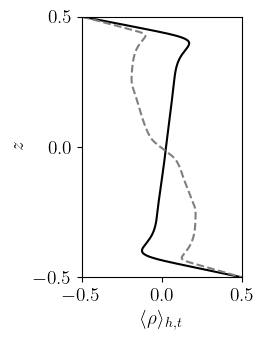

In [9]:

def ypoints(a, b, Ny):
    ypts = np.zeros(Ny)
    c = 0.5 * (b + a)
    r = 0.5 * (b - a)
    piN = np.pi / (Ny - 1)
    for i in range(Ny):
        ypts[i] = c + r * np.cos(piN * i)
    return ypts


y_ddc = ypoints(-0.5,0.5,384)

noslip_ddc = np.loadtxt('Data/DNS/case3_kz6_nx768/noslip_channelflowddc_2steps.csv', delimiter=',')
mtemp_ddc_2steps = noslip_ddc[:, 0]
msalt_ddc_2steps = noslip_ddc[:, 1]
mdens_ddc_2steps = noslip_ddc[:, 2]

noslip_ddc = np.loadtxt('Data/DNS/case3_kz6_nx768/noslip_channelflowddc_1steps.csv', delimiter=',')
mtemp_ddc_1steps = noslip_ddc[:, 0]
msalt_ddc_1steps = noslip_ddc[:, 1]
mdens_ddc_1steps = noslip_ddc[:, 2]


# mtemp_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_temp.csv', delimiter=',')[::-1]
# msalt_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_salt.csv', delimiter=',')[::-1]
# mdens_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/mean_dens.csv', delimiter=',')[::-1]
# tempflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/temp_flux.csv', delimiter=',')[::-1]
# saltflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/salt_flux.csv', delimiter=',')[::-1]
# densflux_yang = np.loadtxt('Case5_YangPaper/free-slip__YangsPaper2022/dens_flux.csv', delimiter=',')[::-1]

fig = plt.figure(figsize=(4.5, 3.5))
ax1 = plt.subplot(1, 2, 1)
plt.plot(mdens_ddc_1steps,y_ddc,color='k', linestyle = 'solid', alpha = 1, label=r'ChFlow--DDC')
plt.plot(mdens_ddc_2steps,y_ddc,color='tab:gray', linestyle = 'dashed', alpha = 1)
# plt.plot(mdens_ddc_4steps,y_ddc,color='k', linestyle = 'solid', alpha = 0.4)
# plt.plot(mdens_yang[:,0],mdens_yang[:,1],color='tab:blue', linestyle = 'dashed', label=r'Yang \textit{et al.} (2022)')
# plt.title(r'$\overline{\rho}$', fontsize=14)
plt.xlabel(r'$\langle \rho \rangle_{h,t}$', fontsize=14)
plt.ylabel(r'$z$',fontsize=14)
plt.xticks([-0.5,0,0.5],fontsize=14)
plt.yticks([-0.5,0,0.5],fontsize=14)
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
# plt.legend()

plt.tight_layout()

# plt.savefig('Data/DNS/case3_kz6_nx768/MeanProfiles_Temp_Salt.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()